In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge
from sklearn.datasets import make_regression
np.random.seed(42)  # FIX: reproducible outliers
np.random.seed(42)  # FIX: reproducible outliers
np.random.seed(42)
# Données presque propres + outliers
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
# Ajout d'outliers très marqués
outliers_idx = np.random.choice(100, size=8, replace=False)
y[outliers_idx] += np.random.normal(80, 30, 8)   # outliers vers le haut

# Modèles
lr = LinearRegression().fit(X, y)
ridge = Ridge(alpha=0.1).fit(X, y)



In [3]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Prédictions
y_pred_ols = lr.predict(X)


# Métriques
def print_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"  R²   = {r2:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MAE  = {mae:.4f}")

# Calcul des métriques de base pour OLS
r2_ols = r2_score(y, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y, y_pred_ols))
mae_ols = mean_absolute_error(y, y_pred_ols)

print_metrics(y, y_pred_ols, 'OLS')

--- OLS ---
  R²   = 0.6611
  RMSE = 27.4688
  MAE  = 15.4490


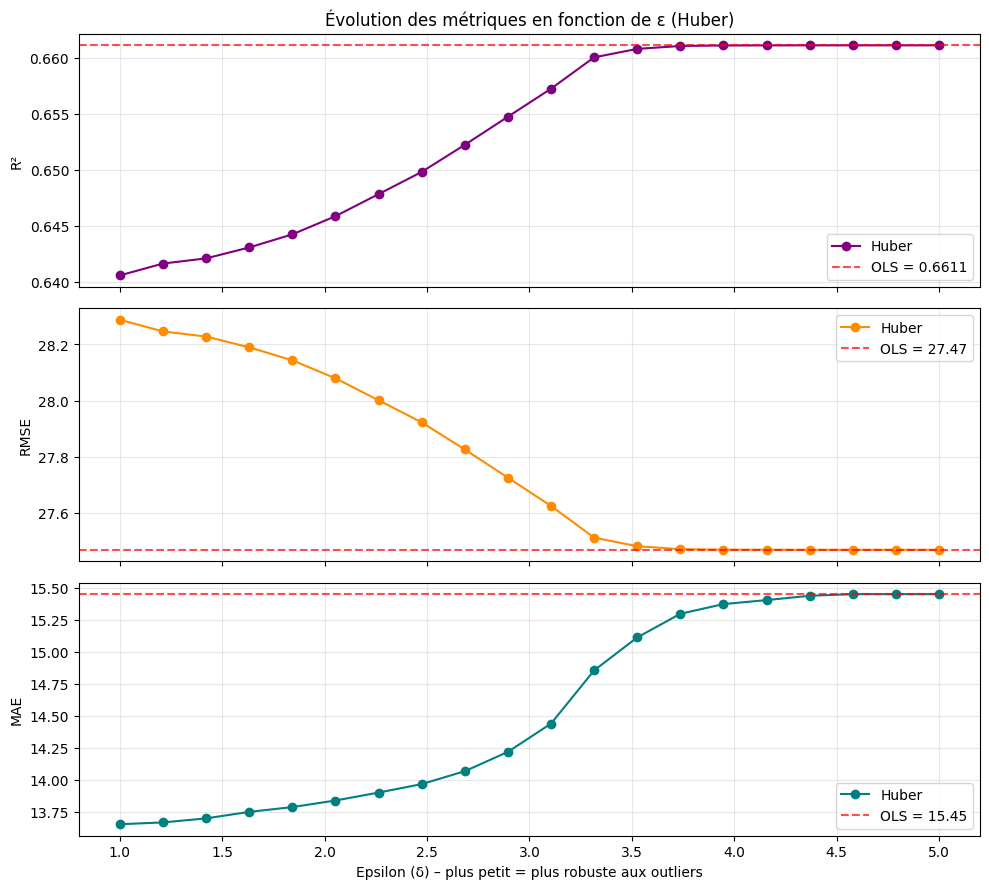

Valeurs pour OLS (référence) :
  R²   = 0.6611    RMSE = 27.47    MAE = 15.45

Huber – epsilon le plus petit testé : 1.0
  R²   = 0.6406    RMSE = 28.29    MAE = 13.65
Huber – epsilon le plus grand testé : 5.0
  R²   = 0.6611    RMSE = 27.47    MAE = 15.45


In [4]:
# ─── Test de plusieurs valeurs d'epsilon ───────────────────────────────────
epsilons = np.linspace(1.0, 5.0, 20)   # FIX: epsilon must be >= 1.0

r2_list   = []
rmse_list = []
mae_list  = []

for eps in epsilons:
    huber = HuberRegressor(epsilon=eps, max_iter=300).fit(X, y)
    y_pred = huber.predict(X)
    
    r2_list.append(  r2_score(y, y_pred) )
    rmse_list.append(np.sqrt(mean_squared_error(y, y_pred)))
    mae_list.append( mean_absolute_error(y, y_pred) )

# ─── Graphique ──────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# R²
ax1.plot(epsilons, r2_list, 'o-', color='purple', label='Huber')
ax1.axhline(r2_ols, color='red', linestyle='--', alpha=0.7, label=f'OLS = {r2_ols:.4f}')
ax1.set_ylabel('R²')
ax1.set_title('Évolution des métriques en fonction de ε (Huber)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RMSE
ax2.plot(epsilons, rmse_list, 'o-', color='darkorange', label='Huber')
ax2.axhline(rmse_ols, color='red', linestyle='--', alpha=0.7, label=f'OLS = {rmse_ols:.2f}')
ax2.set_ylabel('RMSE')
ax2.legend()
ax2.grid(True, alpha=0.3)

# MAE
ax3.plot(epsilons, mae_list, 'o-', color='teal', label='Huber')
ax3.axhline(mae_ols, color='red', linestyle='--', alpha=0.7, label=f'OLS = {mae_ols:.2f}')
ax3.set_ylabel('MAE')
ax3.set_xlabel('Epsilon (δ) – plus petit = plus robuste aux outliers')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Tableau récapitulatif des valeurs extrêmes ─────────────────────────────
print("Valeurs pour OLS (référence) :")
print(f"  R²   = {r2_ols:.4f}    RMSE = {rmse_ols:.2f}    MAE = {mae_ols:.2f}\n")

print("Huber – epsilon le plus petit testé :", epsilons[0])
print(f"  R²   = {r2_list[0]:.4f}    RMSE = {rmse_list[0]:.2f}    MAE = {mae_list[0]:.2f}")

print("Huber – epsilon le plus grand testé :", epsilons[-1])
print(f"  R²   = {r2_list[-1]:.4f}    RMSE = {rmse_list[-1]:.2f}    MAE = {mae_list[-1]:.2f}")

In [5]:
huber = HuberRegressor(epsilon=3.84).fit(X, y)
y_pred_huber = huber.predict(X)
print_metrics(y, y_pred_huber, "Huber")

--- Huber ---
  R²   = 0.6611
  RMSE = 27.4698
  MAE  = 15.3425
